In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.font_manager as fm
import matplotlib

font_path = 'C:\\Windows\\Fonts\\gulim.ttc'
font = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font)

In [63]:
weather_df = pd.read_csv('./data/201511_202511_기온데이터.csv', encoding='cp949')
ele_df = pd.read_csv('./data/electric_202412.csv',skiprows=2)
ele_df_2023 = pd.read_csv('./data/electric_2023.csv',skiprows=2,encoding='cp949')
ele_df_2023

,연도,시도,시군구,계약종별,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월,Unnamed: 16
0,2023,서울특별시,종로구,주택용,"25,002,325","23,457,859","19,732,099","19,571,066","18,879,285","20,820,388","25,770,466","31,732,539","27,333,152","20,318,251","20,011,145","22,240,059",NaN
1,2023,서울특별시,종로구,일반용,"120,952,865","111,104,889","93,861,507","87,142,619","89,355,758","101,804,895","116,257,864","126,086,436","113,869,027","88,813,047","91,840,928","106,587,349",NaN
2,2023,서울특별시,종로구,교육용,"11,323,914","10,147,266","7,825,515","7,091,675","6,616,873","8,111,484","9,471,326","9,915,822","10,102,817","7,206,021","7,645,179","9,794,109",NaN
3,2023,서울특별시,종로구,산업용,"7,072,244","6,736,726","6,165,032","6,111,178","5,443,929","5,945,401","6,268,019","6,302,107","6,558,507","4,836,502","5,198,296","5,778,097",NaN
4,2023,서울특별시,종로구,농사용,631,998,596,746,729,"1,034","1,112","1,016",983,"1,000","1,147","1,494",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1834,2023,세종특별자치시,세종시,산업용,"171,781,806","162,510,140","169,957,652","166,052,437","168,162,478","174,299,216","180,026,875","169,827,829","173,688,967","166,675,649","174,968,508","179,238,996",NaN
1835,2023,세종특별자치시,세종시,농사용,"9,107,122","8,804,685","7,204,538","6,343,243","6,256,407","7,458,240","8,063,135","10,270,110","9,942,964","6,982,949","9,516,506","7,236,121",NaN
1836,2023,세종특별자치시,세종시,가로등,"3,609,372","3,423,521","3,114,626","3,108,297","2,859,398","2,905,021","2,738,134","2,734,316","2,905,209","3,078,369","3,346,673","3,473,666",NaN
1837,2023,세종특별자치시,세종시,심 야,"12,171,933","11,508,842","8,070,399","5,605,594","3,567,637","2,061,346","1,601,097","1,661,365","1,548,227","2,187,341","4,704,291","8,444,545",NaN


In [64]:
df = weather_df[weather_df['지점명']=='서울']
df.info()

df['일시'] = df['일시'].sort_values()
df

<class 'pandas.core.frame.DataFrame'>
Index: 121 entries, 1320 to 1440
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   지점                  121 non-null    int64  
 1   지점명                 121 non-null    object 
 2   일시                  121 non-null    object 
 3   평균기온(°C)            121 non-null    float64
 4   평균최고기온(°C)          121 non-null    float64
 5   평균최저기온(°C)          121 non-null    float64
 6   최고기온(°C)            121 non-null    float64
 7   최저기온(°C)            121 non-null    float64
 8   평균현지기압(hPa)         121 non-null    float64
 9   평균해면기압(hPa)         121 non-null    float64
 10  평균수증기압(hPa)         121 non-null    float64
 11  평균상대습도(%)           121 non-null    float64
 12  월합강수량(00~24h만)(mm)  121 non-null    float64
 13  일최다강수량(mm)          121 non-null    float64
 14  소형총증발량(mm)          121 non-null    float64
 15  대형총증발량(mm)          116 non-null    float64
 16  평균풍속(m/s)

C:\Users\parks\AppData\Local\Temp\ipykernel_24000\309259466.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['일시'] = df['일시'].sort_values()


,지점,지점명,일시,평균기온(°C),평균최고기온(°C),평균최저기온(°C),최고기온(°C),최저기온(°C),평균현지기압(hPa),평균해면기압(hPa),...,평균중하층운량(1/10),일조율(%),합계 일사량(MJ/m2),최심적설(cm),최심신적설(cm),평균 최저초상온도(°C),평균지면온도(°C),0.5m평균지중온도(°C),1.5m평균지중온도(°C),3.0m평균지중온도(°C)
1320,108,서울,2015-11,8.9,12.7,5.9,21.0,-7.3,1012.9,1023.4,...,4.4,35.64,177.93,NaN,NaN,3.0,9.5,12.9,17.0,18.8
1321,108,서울,2015-12,1.6,6.0,-2.1,12.2,-9.5,1014.8,1025.6,...,2.7,59.48,206.35,6.5,6.5,-5.4,2.2,6.3,12.2,16.8
1322,108,서울,2016-01,-3.2,1.1,-6.8,9.5,-18.0,1014.5,1025.5,...,2.6,63.86,246.52,0.5,0.5,-10.3,-1.4,2.8,8.5,14.4
1323,108,서울,2016-02,0.2,5.1,-4.1,14.4,-10.0,1013.3,1024.2,...,2.3,62.26,288.43,5.0,5.0,-7.9,1.1,1.9,6.2,12.3
1324,108,서울,2016-03,7.0,12.6,2.4,21.4,-7.5,1010.9,1021.5,...,1.9,68.29,432.76,NaN,NaN,-1.5,9.1,6.9,7.4,10.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,108,서울,2025-07,28.8,32.6,25.7,38.0,21.5,996.2,1005.8,...,4.1,38.99,538.53,NaN,NaN,22.9,30.2,26.5,22.7,18.3
1437,108,서울,2025-08,28.2,31.9,25.3,36.2,21.0,997.9,1007.5,...,4.3,35.68,485.65,NaN,NaN,22.8,28.9,27.8,25.3,20.8
1438,108,서울,2025-09,23.5,27.4,20.3,33.0,16.6,1002.2,1012.0,...,3.8,37.25,393.58,NaN,NaN,17.1,23.5,25.6,25.7,22.8
1439,108,서울,2025-10,16.5,20.4,13.1,28.0,3.0,1009.2,1019.3,...,4.5,32.93,297.37,NaN,NaN,10.2,16.6,20.2,22.8,22.5


In [65]:
seoul_df = ele_df[(ele_df['시도']=='서울특별시')]
seoul_df_2023 = ele_df_2023[(ele_df_2023['시도']=='서울특별시')]
seoul_df_2023.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199 entries, 0 to 198
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   연도           199 non-null    int64  
 1   시도           199 non-null    object 
 2   시군구          199 non-null    object 
 3   계약종별         199 non-null    object 
 4   1월           199 non-null    object 
 5   2월           199 non-null    object 
 6   3월           199 non-null    object 
 7   4월           199 non-null    object 
 8   5월           199 non-null    object 
 9   6월           199 non-null    object 
 10  7월           199 non-null    object 
 11  8월           199 non-null    object 
 12  9월           199 non-null    object 
 13  10월          199 non-null    object 
 14  11월          199 non-null    object 
 15  12월          199 non-null    object 
 16  Unnamed: 16  0 non-null      float64
dtypes: float64(1), int64(1), object(15)
memory usage: 28.0+ KB


In [66]:
df_2015 = df[df['일시'].str[:4]=='2015']
df_2016 = df[df['일시'].str[:4]=='2016']
df_2017 = df[df['일시'].str[:4]=='2017']
df_2018 = df[df['일시'].str[:4]=='2018']
df_2019 = df[df['일시'].str[:4]=='2019']
df_2020 = df[df['일시'].str[:4]=='2020']
df_2021 = df[df['일시'].str[:4]=='2021']
df_2022 = df[df['일시'].str[:4]=='2022']
df_2023 = df[df['일시'].str[:4]=='2023']
df_2024 = df[df['일시'].str[:4]=='2024']

In [67]:
# 전력량 정수형 변환
ele_df['1월'] = ele_df['1월'].astype(str).str.replace(',', '', regex=False).astype(float)
ele_df['2월'] = ele_df['2월'].astype(str).str.replace(',', '', regex=False).astype(float)
ele_df['3월'] = ele_df['3월'].astype(str).str.replace(',', '', regex=False).astype(float)
ele_df['4월'] = ele_df['4월'].astype(str).str.replace(',', '', regex=False).astype(float)
ele_df['5월'] = ele_df['5월'].astype(str).str.replace(',', '', regex=False).astype(float)
ele_df['6월'] = ele_df['6월'].astype(str).str.replace(',', '', regex=False).astype(float)
ele_df['7월'] = ele_df['7월'].astype(str).str.replace(',', '', regex=False).astype(float)

ele_df['8월'] = pd.to_numeric(ele_df['8월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df['9월'] = pd.to_numeric(ele_df['9월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df['10월'] = pd.to_numeric(ele_df['10월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df['11월'] = pd.to_numeric(ele_df['11월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df['12월'] = pd.to_numeric(ele_df['12월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')

ele_df_2023['1월'] = pd.to_numeric(ele_df_2023['1월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df_2023['2월'] = pd.to_numeric(ele_df_2023['2월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df_2023['3월'] = pd.to_numeric(ele_df_2023['3월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df_2023['4월'] = pd.to_numeric(ele_df_2023['4월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df_2023['5월'] = pd.to_numeric(ele_df_2023['5월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df_2023['6월'] = pd.to_numeric(ele_df_2023['6월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df_2023['7월'] = pd.to_numeric(ele_df_2023['7월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')

ele_df_2023['8월'] = pd.to_numeric(ele_df_2023['8월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df_2023['9월'] = pd.to_numeric(ele_df_2023['9월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df_2023['10월'] = pd.to_numeric(ele_df_2023['10월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df_2023['11월'] = pd.to_numeric(ele_df_2023['11월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')
ele_df_2023['12월'] = pd.to_numeric(ele_df_2023['12월'].astype(str).str.replace(',', '', regex=False).replace('-', np.nan), errors='coerce')


In [68]:
seoul_ele_df = ele_df[(ele_df['시도']=='서울특별시') & (ele_df['계약종별']=='합 계')]
seoul_ele_df_2023 = ele_df_2023[(ele_df_2023['시도']=='서울특별시') & (ele_df_2023['계약종별']=='합 계')]

In [69]:
seoul_ele_df_2023

,연도,시도,시군구,계약종별,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월,Unnamed: 16
7,2023,서울특별시,종로구,합 계,167577439.0,154470846.0,129934521.0,122187609.0,124428697.0,142089043.0,165235169.0,181857199.0,163859904.0,123553585.0,126485939.0,146790144.0,NaN
15,2023,서울특별시,중구,합 계,219236584.0,198215053.0,171841502.0,161591556.0,171438226.0,196608044.0,229388113.0,248137929.0,221743563.0,168438050.0,172682137.0,196658062.0,NaN
22,2023,서울특별시,용산구,합 계,146757364.0,135385837.0,114244547.0,111414515.0,112035067.0,127144170.0,148869775.0,170646247.0,153535026.0,118229151.0,118063333.0,131810656.0,NaN
30,2023,서울특별시,성동구,합 계,211473758.0,197073263.0,169758338.0,164736191.0,161581470.0,176517118.0,200459744.0,229555550.0,212697689.0,167328350.0,168816715.0,186914025.0,NaN
38,2023,서울특별시,동대문구,합 계,143234883.0,133447123.0,110087552.0,105776071.0,102048309.0,113729076.0,133649686.0,157225586.0,145577528.0,110609104.0,108264335.0,125106185.0,NaN
46,2023,서울특별시,성북구,합 계,145299842.0,136609915.0,112577415.0,109191719.0,105372107.0,116242754.0,134045410.0,157891001.0,146560842.0,111795406.0,112113844.0,127903683.0,NaN
54,2023,서울특별시,도봉구,합 계,87631592.0,81855951.0,67243183.0,65623786.0,62263715.0,67709026.0,80482421.0,95134861.0,83917704.0,65304657.0,66070945.0,75778797.0,NaN
62,2023,서울특별시,은평구,합 계,142241984.0,135178819.0,112099452.0,109708945.0,105025517.0,114685604.0,135493426.0,162384275.0,147086738.0,113417856.0,112281393.0,125693192.0,NaN
70,2023,서울특별시,서대문구,합 계,123440402.0,113082975.0,97971710.0,93685930.0,94466306.0,105185921.0,124131290.0,141538075.0,125057373.0,96878389.0,98638033.0,112108539.0,NaN
78,2023,서울특별시,마포구,합 계,211982695.0,195713864.0,168086913.0,160911026.0,164851628.0,182678600.0,213272524.0,242079018.0,218100613.0,171320332.0,168500002.0,192650461.0,NaN


In [70]:
seoul_df1 = seoul_ele_df[seoul_ele_df['시도']=='서울특별시']['1월'].mean()
seoul_df2 = seoul_ele_df[seoul_ele_df['시도']=='서울특별시']['2월'].mean()
seoul_df3 = seoul_ele_df[seoul_ele_df['시도']=='서울특별시']['3월'].mean()
seoul_df4 = seoul_ele_df[seoul_ele_df['시도']=='서울특별시']['4월'].mean()
seoul_df5 = seoul_ele_df[seoul_ele_df['시도']=='서울특별시']['5월'].mean()
seoul_df6 = seoul_ele_df[seoul_ele_df['시도']=='서울특별시']['6월'].mean()
seoul_df7 = seoul_ele_df[seoul_ele_df['시도']=='서울특별시']['7월'].mean()
seoul_df8 = seoul_ele_df[seoul_ele_df['시도']=='서울특별시']['8월'].mean()
seoul_df9 = seoul_ele_df[seoul_ele_df['시도']=='서울특별시']['9월'].mean()
seoul_df10 =seoul_ele_df[seoul_ele_df['시도']=='서울특별시']['10월'].mean()
seoul_df11 =seoul_ele_df[seoul_ele_df['시도']=='서울특별시']['11월'].mean()
seoul_df12 =seoul_ele_df[seoul_ele_df['시도']=='서울특별시']['12월'].mean()

In [71]:
seoul_df1_2023 = seoul_ele_df_2023[seoul_ele_df_2023['시도']=='서울특별시']['1월'].mean()
seoul_df2_2023 = seoul_ele_df_2023[seoul_ele_df_2023['시도']=='서울특별시']['2월'].mean()
seoul_df3_2023 = seoul_ele_df_2023[seoul_ele_df_2023['시도']=='서울특별시']['3월'].mean()
seoul_df4_2023 = seoul_ele_df_2023[seoul_ele_df_2023['시도']=='서울특별시']['4월'].mean()
seoul_df5_2023 = seoul_ele_df_2023[seoul_ele_df_2023['시도']=='서울특별시']['5월'].mean()
seoul_df6_2023 = seoul_ele_df_2023[seoul_ele_df_2023['시도']=='서울특별시']['6월'].mean()
seoul_df7_2023 = seoul_ele_df_2023[seoul_ele_df_2023['시도']=='서울특별시']['7월'].mean()
seoul_df8_2023 = seoul_ele_df_2023[seoul_ele_df_2023['시도']=='서울특별시']['8월'].mean()
seoul_df9_2023 = seoul_ele_df_2023[seoul_ele_df_2023['시도']=='서울특별시']['9월'].mean()
seoul_df10_2023 =seoul_ele_df_2023[seoul_ele_df_2023['시도']=='서울특별시']['10월'].mean()
seoul_df11_2023 =seoul_ele_df_2023[seoul_ele_df_2023['시도']=='서울특별시']['11월'].mean()
seoul_df12_2023 =seoul_ele_df_2023[seoul_ele_df_2023['시도']=='서울특별시']['12월'].mean()

In [72]:
ele_df[ele_df['시도']=='서울특별시']['1월']

0       24457510.0
1      118970820.0
2       10915579.0
3        5977510.0
4           1314.0
          ...     
194     19778322.0
195         4511.0
196       691468.0
197       216650.0
198    161919097.0
Name: 1월, Length: 199, dtype: float64

In [73]:
seoul_df = pd.DataFrame({
    '1월': [seoul_df1],
    '2월': [seoul_df2],
    '3월': [seoul_df3],
    '4월': [seoul_df4],
    '5월': [seoul_df5],
    '6월': [seoul_df6],
    '7월': [seoul_df7],
    '8월': [seoul_df8],
    '9월': [seoul_df9],
    '10월': [seoul_df10],
    '11월': [seoul_df11],
    '12월': [seoul_df12],
})

seoul_df_2023 = pd.DataFrame({
    '1월': [seoul_df1_2023],
    '2월': [seoul_df2_2023],
    '3월': [seoul_df3_2023],
    '4월': [seoul_df4_2023],
    '5월': [seoul_df5_2023],
    '6월': [seoul_df6_2023],
    '7월': [seoul_df7_2023],
    '8월': [seoul_df8_2023],
    '9월': [seoul_df9_2023],
    '10월': [seoul_df10_2023],
    '11월': [seoul_df11_2023],
    '12월': [seoul_df12_2023],
})

In [74]:
seoul_df

,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
0,1.813333e+08,1.708541e+08,1.523343e+08,1.443881e+08,1.388465e+08,1.559232e+08,1.839772e+08,2.188780e+08,206886053.8,155499336.6,1.433240e+08,1.618357e+08


In [75]:
seoul_val = seoul_df.to_numpy().T
seoul_val_2023 = seoul_df_2023.to_numpy().T

In [76]:
seoul_df_2023

,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
0,186196661.0,172517160.4,1.458523e+08,1.400994e+08,1.389462e+08,154711723.6,1.813061e+08,2.080045e+08,187294325.8,1.446525e+08,144867491.4,1.643101e+08


In [77]:
df_2024['전력량'] = seoul_val
df_2023['전력량'] = seoul_val_2023

C:\Users\parks\AppData\Local\Temp\ipykernel_24000\3894961313.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024['전력량'] = seoul_val
C:\Users\parks\AppData\Local\Temp\ipykernel_24000\3894961313.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2023['전력량'] = seoul_val_2023


In [85]:
df_final_24 = df_2024[['지점명','일시','평균기온(°C)','평균현지기압(hPa)','평균해면기압(hPa)','평균수증기압(hPa)','평균상대습도(%)','월합강수량(00~24h만)(mm)','평균풍속(m/s)','일조율(%)','평균지면온도(°C)','최심적설(cm)','전력량']].fillna(0)
df_final_24
df_final_23 = df_2023[['지점명','일시','평균기온(°C)','평균현지기압(hPa)','평균해면기압(hPa)','평균수증기압(hPa)','평균상대습도(%)','월합강수량(00~24h만)(mm)','평균풍속(m/s)','일조율(%)','평균지면온도(°C)','최심적설(cm)','전력량']].fillna(0)
df_final_23

df_final_23_24 = pd.concat((df_final_23,df_final_24))

df_final_23_24

,지점명,일시,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),평균지면온도(°C),최심적설(cm),전력량
1406,서울,2023-01,-1.5,1013.7,1024.6,3.8,63.0,47.9,2.4,62.16,-1.2,4.5,1.861967e+08
1407,서울,2023-02,2.3,1014.8,1025.6,4.3,59.0,1.0,2.3,65.52,2.0,0.0,1.725172e+08
1408,서울,2023-03,9.8,1009.4,1019.8,6.2,51.0,10.5,2.3,64.71,9.9,0.0,1.458523e+08
1409,서울,2023-04,13.8,1004.0,1014.2,9.1,60.0,96.9,2.5,46.18,15.6,0.0,1.400994e+08
1410,서울,2023-05,19.5,1002.4,1012.4,14.0,63.0,155.6,2.3,53.57,23.2,0.0,1.389462e+08
1411,서울,2023-06,23.4,996.5,1006.2,20.5,73.0,195.6,2.2,44.13,26.5,0.0,1.547117e+08
1412,서울,2023-07,26.7,996.9,1006.6,28.0,81.0,459.9,2.1,32.55,28.2,0.0,1.813061e+08
1413,서울,2023-08,27.2,995.1,1004.8,27.1,76.0,298.1,2.2,37.03,29.2,0.0,2.080045e+08
1414,서울,2023-09,23.7,1002.5,1012.3,21.2,74.0,134.5,2.0,42.06,25.4,0.0,1.872943e+08
1415,서울,2023-10,15.8,1008.0,1018.1,11.8,67.0,31.0,1.9,59.85,16.1,0.0,1.446525e+08


<Axes: >

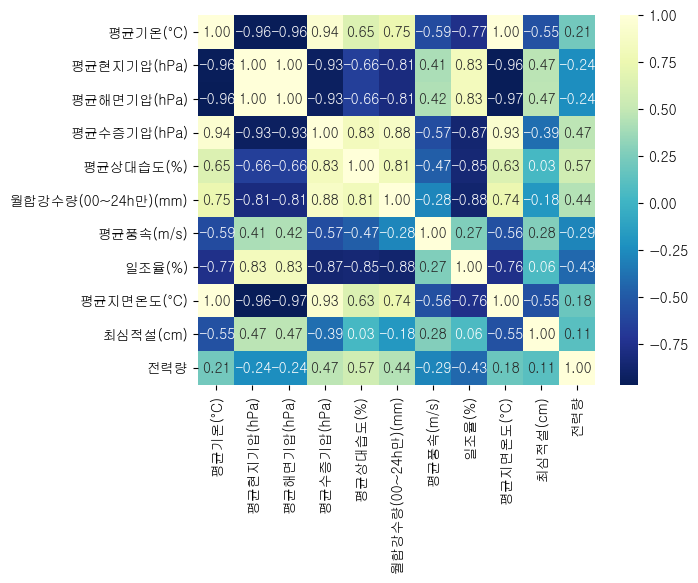

In [79]:
corr_matrix = df_final_23.corr(numeric_only=True)
corr_matrix
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='YlGnBu_r')

<Axes: >

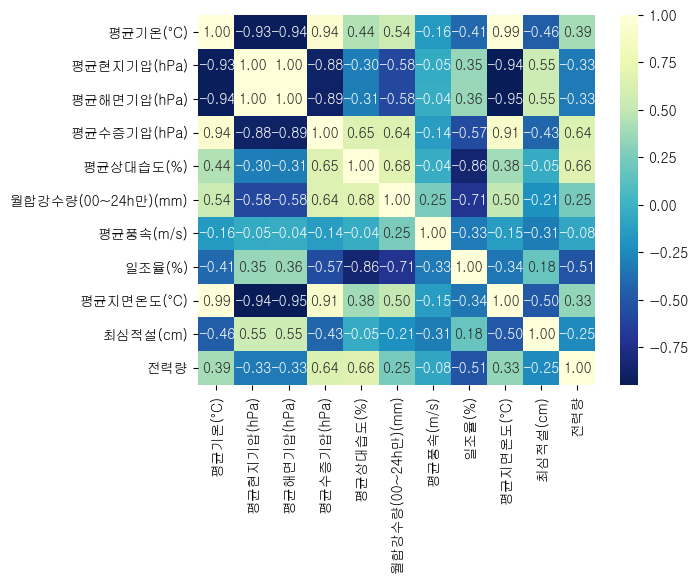

In [80]:
corr_matrix = df_final_24.corr(numeric_only=True)
corr_matrix
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='YlGnBu_r')

In [ ]:
df_fina

<Axes: >

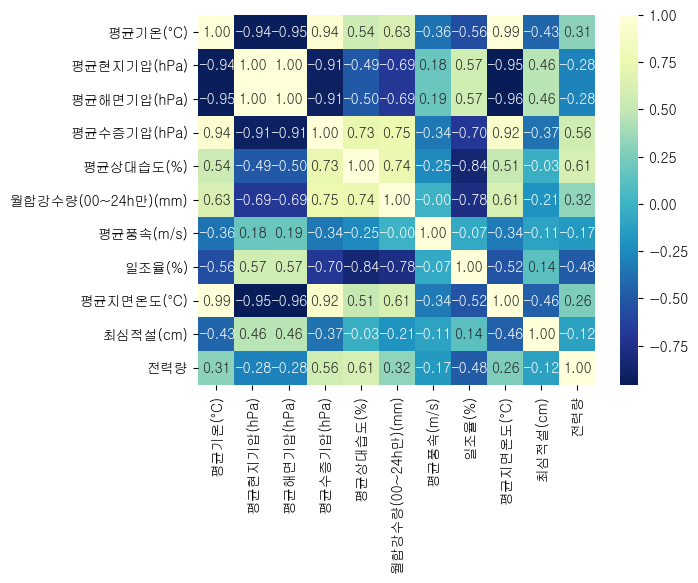

In [81]:
corr_matrix = df_final_23_24.corr(numeric_only=True)
corr_matrix
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='YlGnBu_r')

C:\Users\parks\AppData\Local\Temp\ipykernel_24000\3780890763.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024['일시'] = pd.to_datetime(df_2024['일시'], errors='coerce')


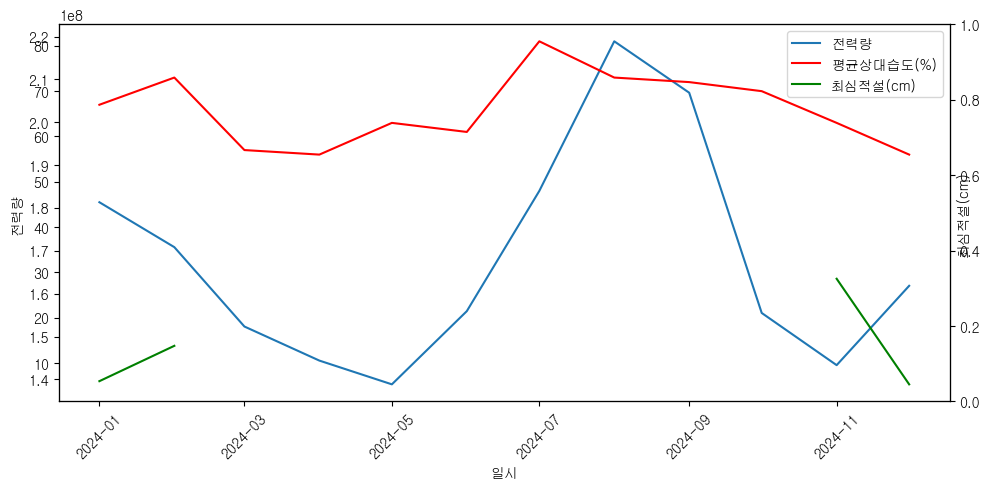

In [82]:
import matplotlib.pyplot as plt
import pandas as pd

df_2024['일시'] = pd.to_datetime(df_2024['일시'], errors='coerce')
df_2024 = df_2024.dropna(subset=['일시']).sort_values('일시')

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df_2024['일시'], df_2024['전력량'], label='전력량')
ax1.set_xlabel('일시')
ax1.set_ylabel('전력량')

ax2 = ax1.twinx()
ax2.plot(df_2024['일시'], df_2024['평균상대습도(%)'], label='평균상대습도(%)',color='red')
ax2.set_ylabel('평균상대습도(%)')

ax3 = ax2.twinx()
ax2.plot(df_2024['일시'], df_2024['최심적설(cm)'], label='최심적설(cm)',color='green')
ax2.set_ylabel('최심적설(cm)')

ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()


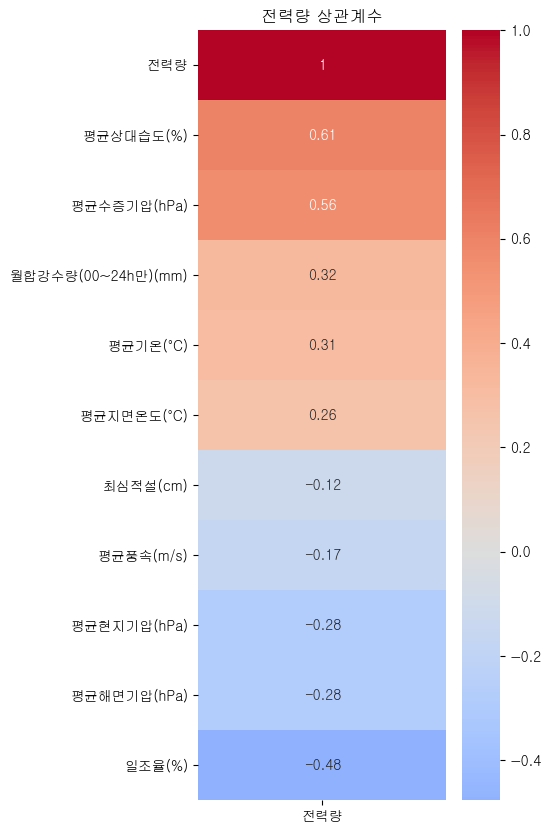

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

num_df = df_final_23_24.select_dtypes(include='number')

corr = num_df.corr()
corr_power = corr[['전력량']].sort_values(by='전력량', ascending=False)

plt.figure(figsize=(4, 10))
sns.heatmap(corr_power, annot=True, cmap='coolwarm', center=0)
plt.title('전력량 상관계수')
plt.show()



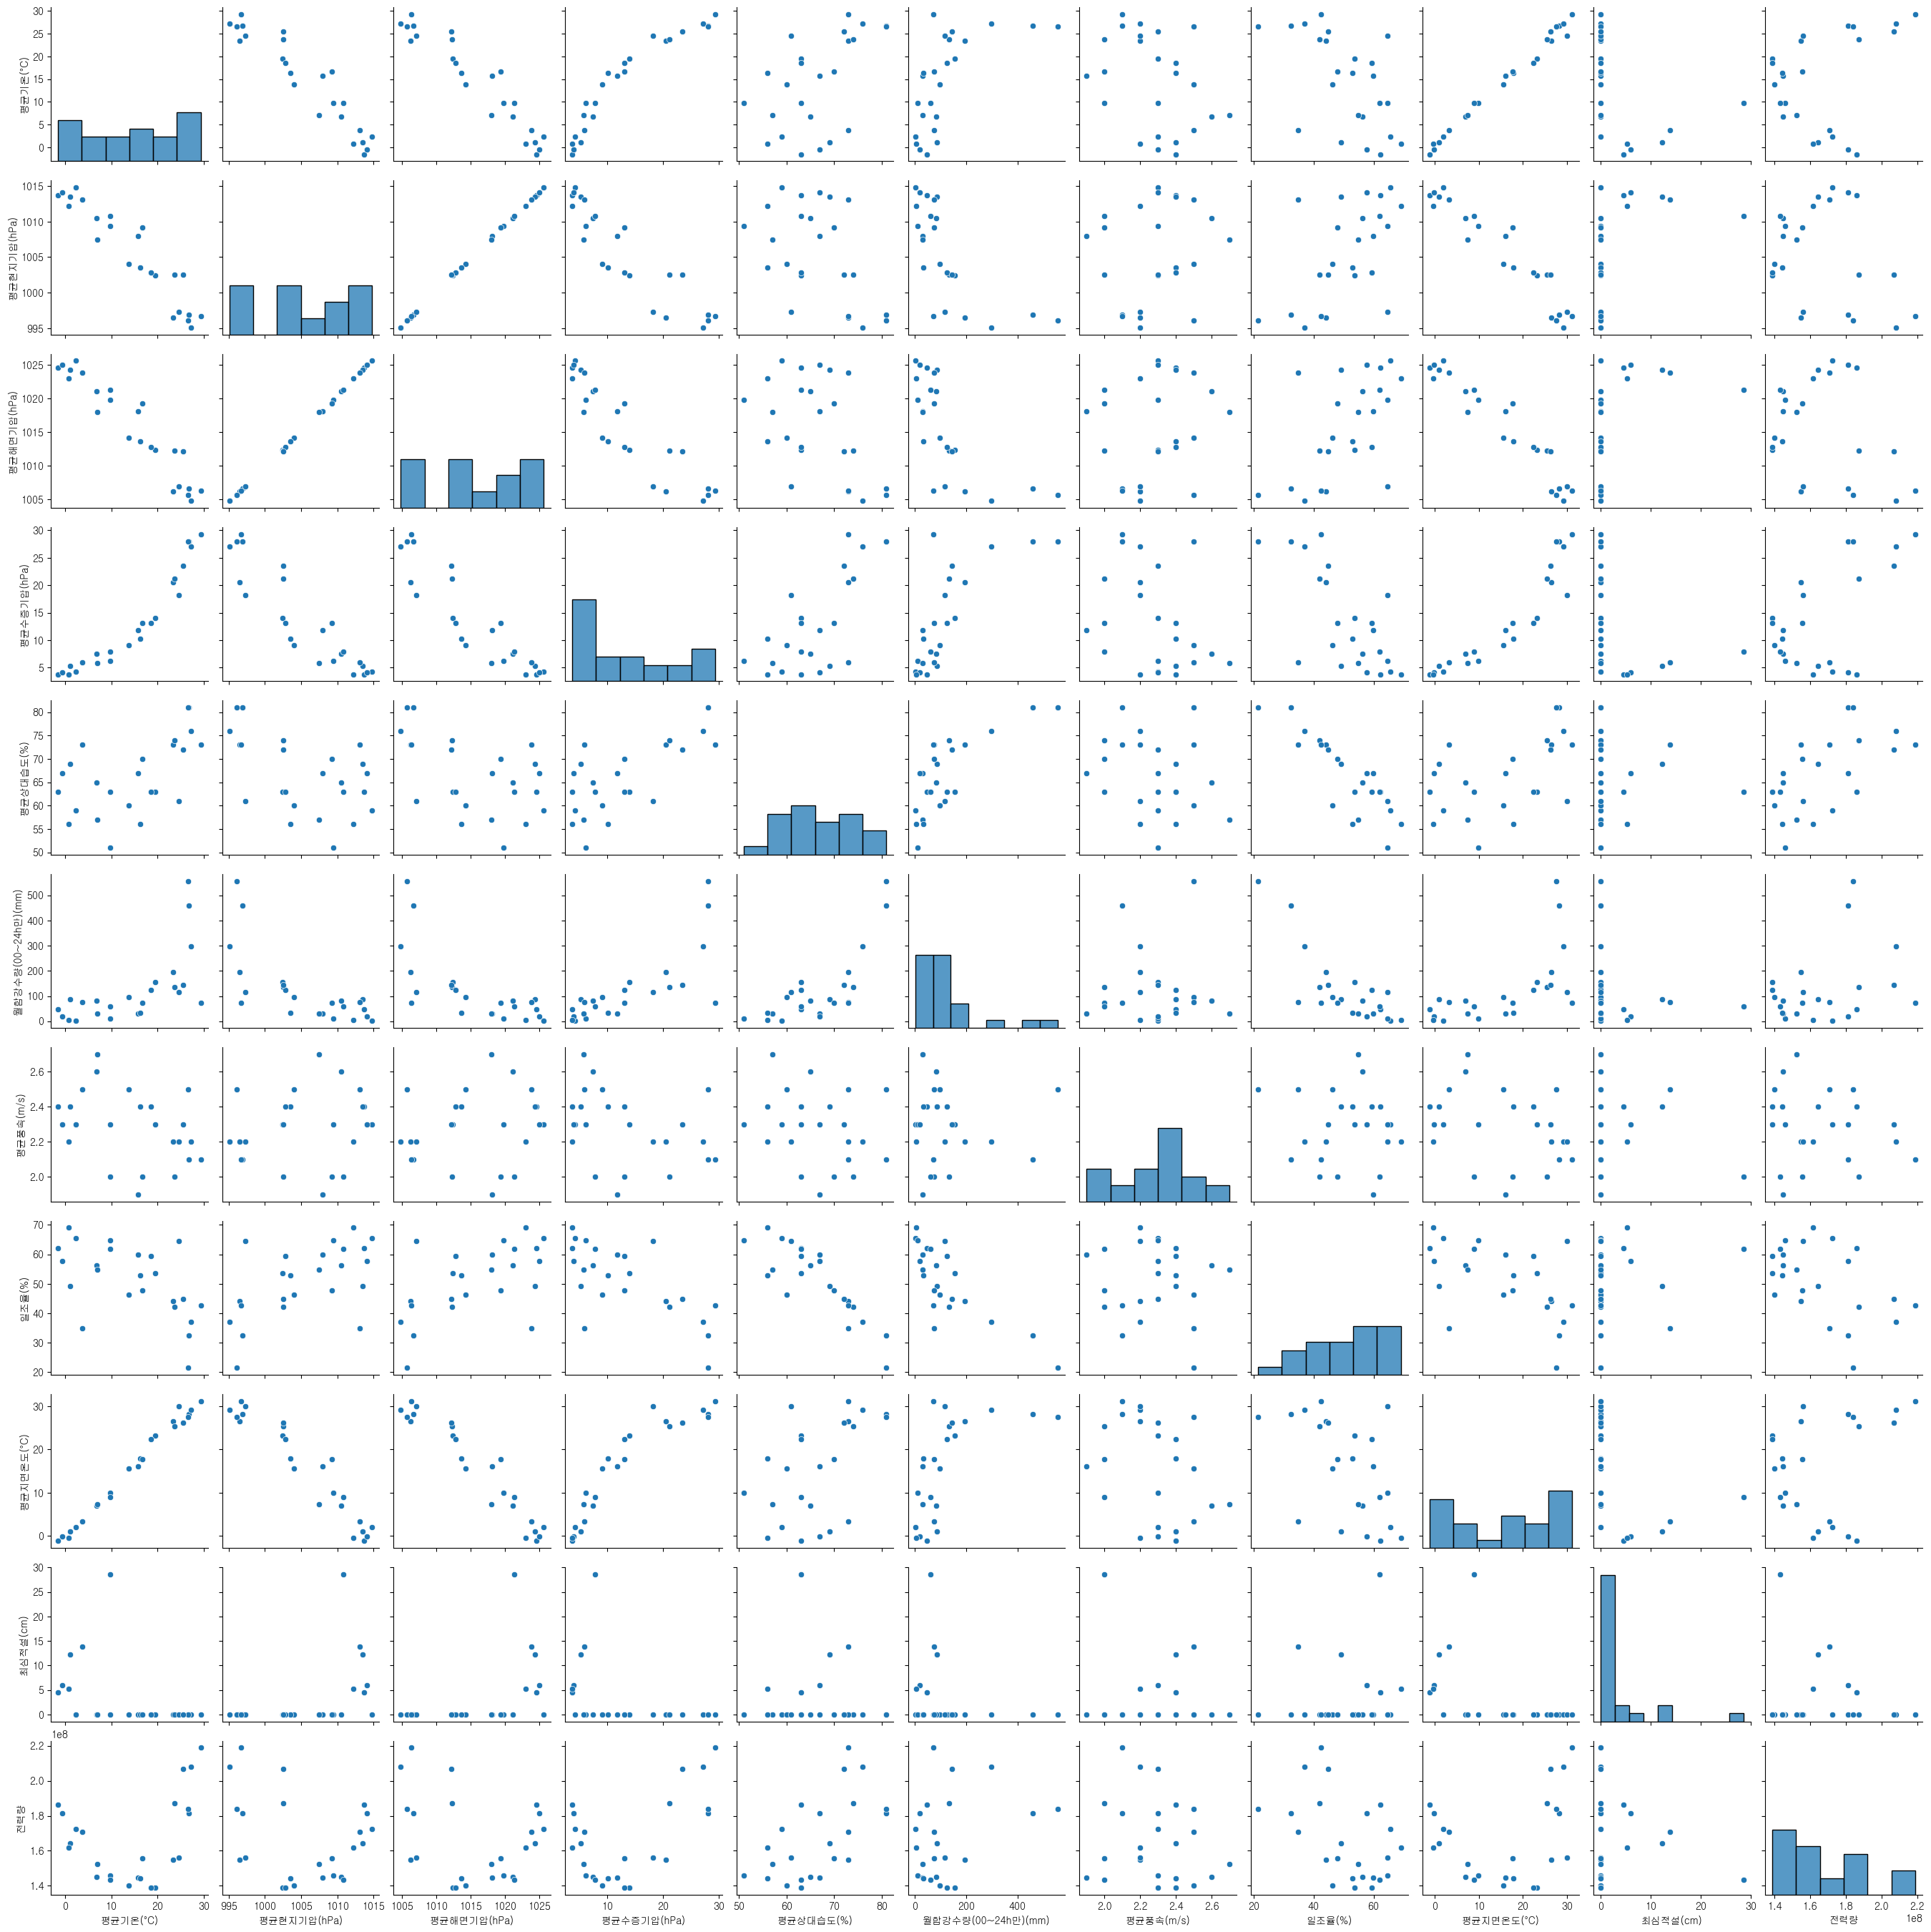

In [84]:
sns.pairplot(df_final_23_24)